# NASA SMAP Anomaly Detection — Exploratory Data Analysis

This notebook explores the NASA SMAP sensor telemetry dataset used for real-time anomaly detection.

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from pathlib import Path
import sys

sys.path.insert(0, str(Path('..').resolve()))

from src.config import DATA_DIR, WINDOW_SIZE, STEP_SIZE
from src.data_loader import load_entity, load_labels, sliding_windows, normalize
from src.features import extract_features, feature_names

plt.style.use('dark_background')
sns.set_palette('husl')

ENTITY = 'P-1'

## 1. Dataset Overview

In [3]:
train_data = load_entity(ENTITY, split='train')
test_data = load_entity(ENTITY, split='test')
labels = load_labels(ENTITY)

print(f'Entity: {ENTITY}')
print(f'Train shape: {train_data.shape} — {train_data.shape[0]} timesteps, {train_data.shape[1]} channels')
print(f'Test shape:  {test_data.shape}')
print(f'Anomaly timesteps: {labels.sum()} / {len(labels)} ({labels.mean()*100:.1f}%)')

Entity: P-1
Train shape: (2872, 25) — 2872 timesteps, 25 channels
Test shape:  (8505, 25)
Anomaly timesteps: 751 / 8505 (8.8%)


## 2. Primary Channel — Train vs Test

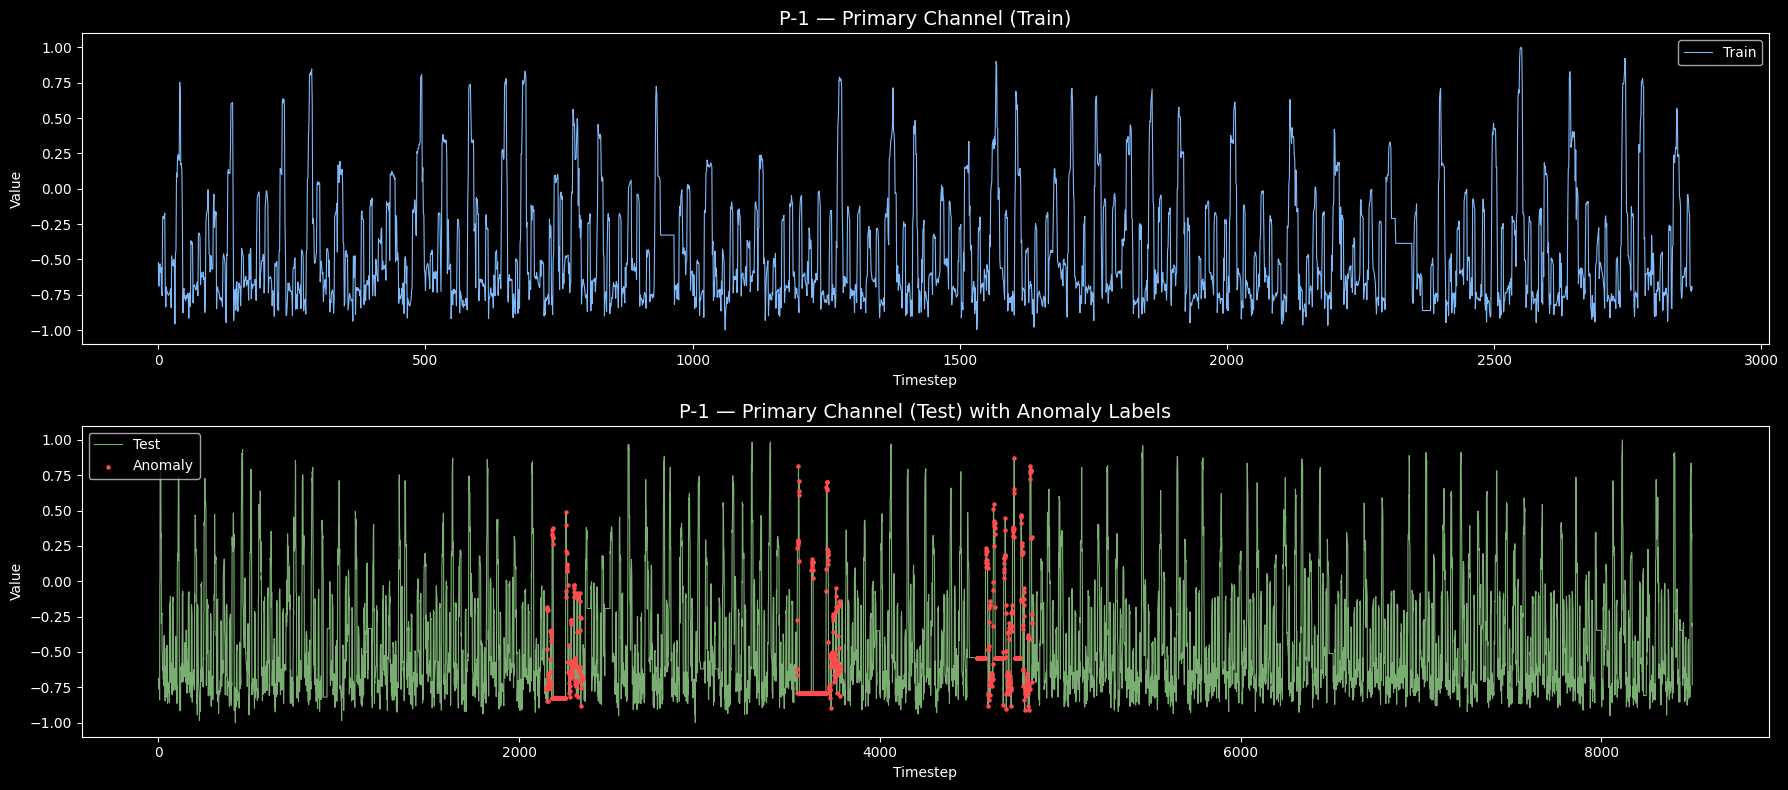

In [4]:
fig, axes = plt.subplots(2, 1, figsize=(18, 8))

axes[0].plot(train_data[:, 0], linewidth=0.8, color='#7eb8f7', label='Train')
axes[0].set_title(f'{ENTITY} — Primary Channel (Train)', fontsize=14)
axes[0].set_xlabel('Timestep')
axes[0].set_ylabel('Value')
axes[0].legend()

axes[1].plot(test_data[:, 0], linewidth=0.8, color='#98d98e', label='Test', alpha=0.8)
if labels is not None:
    anomaly_idx = np.where(labels == 1)[0]
    axes[1].scatter(anomaly_idx, test_data[anomaly_idx, 0], color='#ff4b4b', s=5, label='Anomaly', zorder=5)
axes[1].set_title(f'{ENTITY} — Primary Channel (Test) with Anomaly Labels', fontsize=14)
axes[1].set_xlabel('Timestep')
axes[1].set_ylabel('Value')
axes[1].legend()

plt.tight_layout()
plt.show()

## 3. All Channels Heatmap

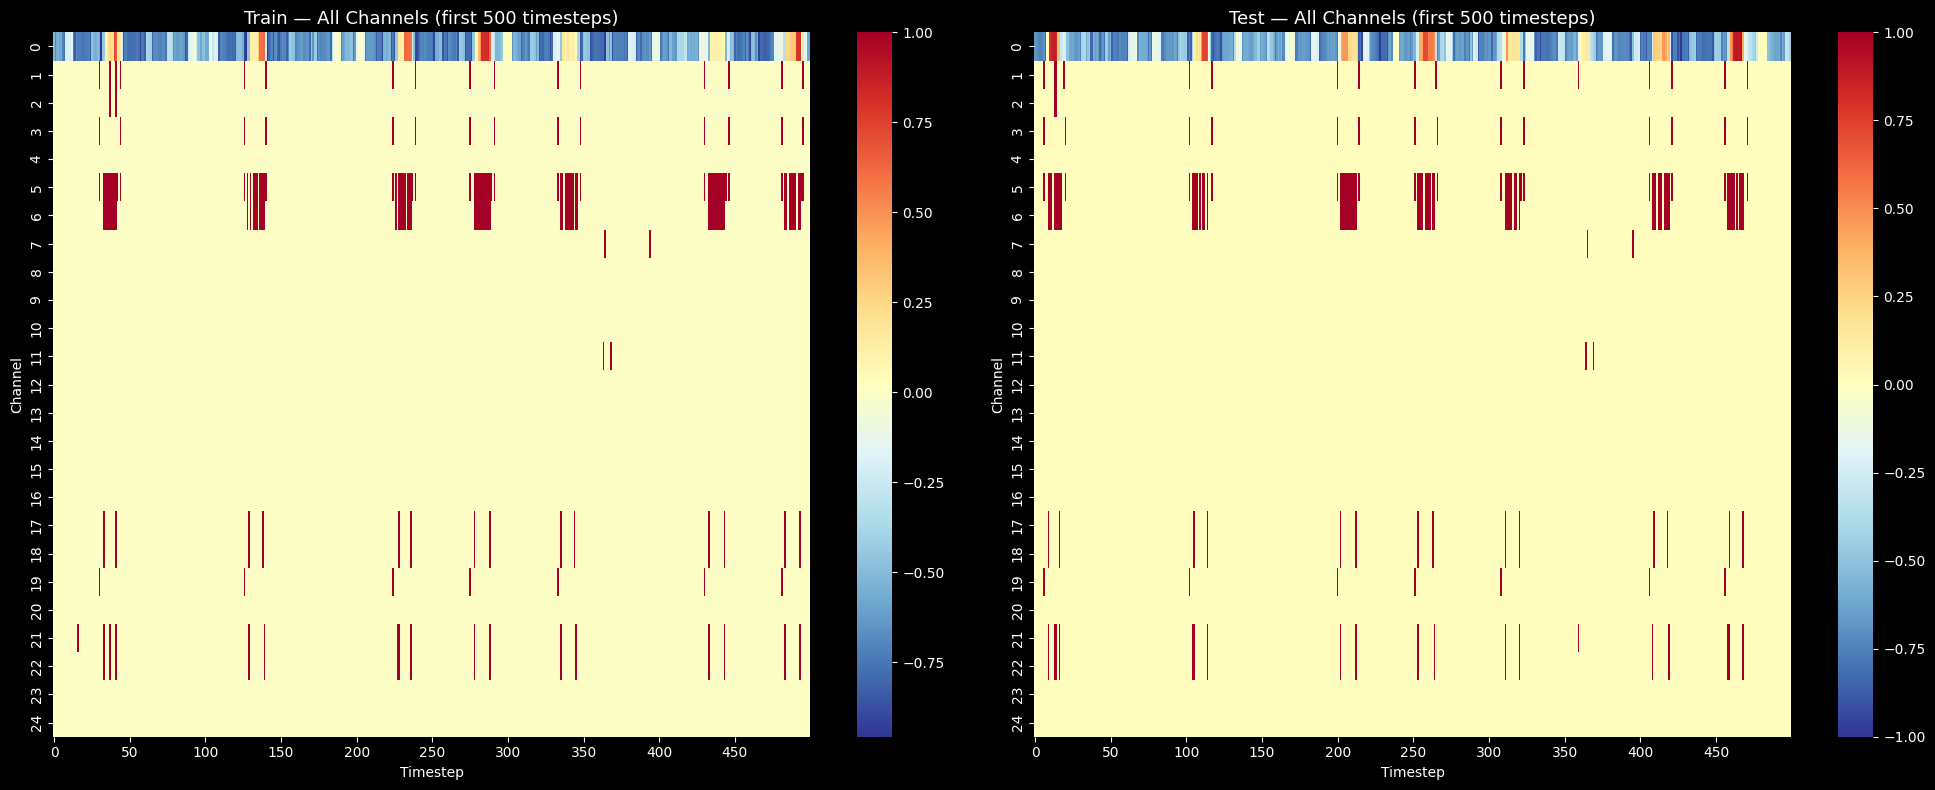

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(20, 8))

sns.heatmap(train_data[:500].T, ax=axes[0], cmap='RdYlBu_r', xticklabels=50)
axes[0].set_title('Train — All Channels (first 500 timesteps)', fontsize=13)
axes[0].set_xlabel('Timestep')
axes[0].set_ylabel('Channel')

sns.heatmap(test_data[:500].T, ax=axes[1], cmap='RdYlBu_r', xticklabels=50)
axes[1].set_title('Test — All Channels (first 500 timesteps)', fontsize=13)
axes[1].set_xlabel('Timestep')
axes[1].set_ylabel('Channel')

plt.tight_layout()
plt.show()

## 4. Distribution Analysis

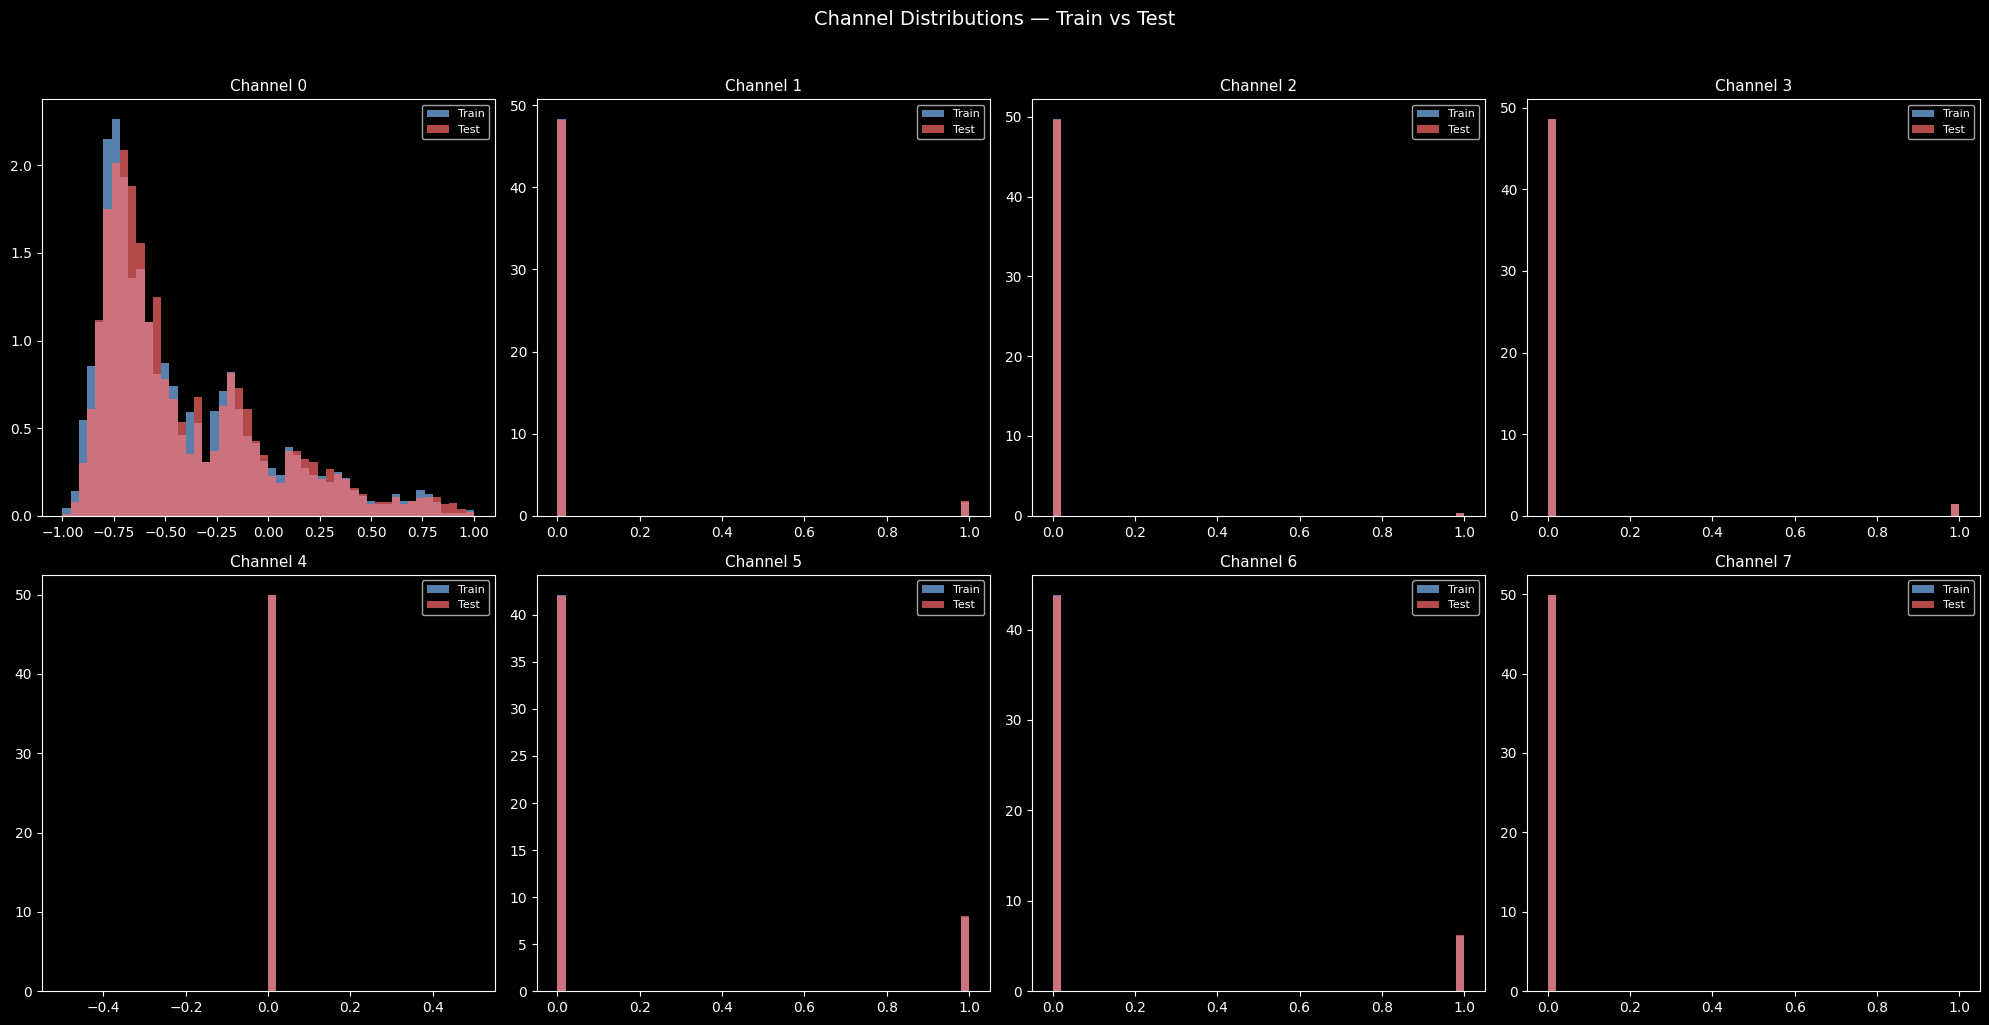

In [6]:
fig, axes = plt.subplots(2, 4, figsize=(20, 10))
axes = axes.flatten()

for i in range(min(8, train_data.shape[1])):
    axes[i].hist(train_data[:, i], bins=50, alpha=0.7, color='#7eb8f7', label='Train', density=True)
    axes[i].hist(test_data[:, i], bins=50, alpha=0.7, color='#ff6b6b', label='Test', density=True)
    axes[i].set_title(f'Channel {i}', fontsize=11)
    axes[i].legend(fontsize=8)

plt.suptitle('Channel Distributions — Train vs Test', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

## 5. Correlation Matrix

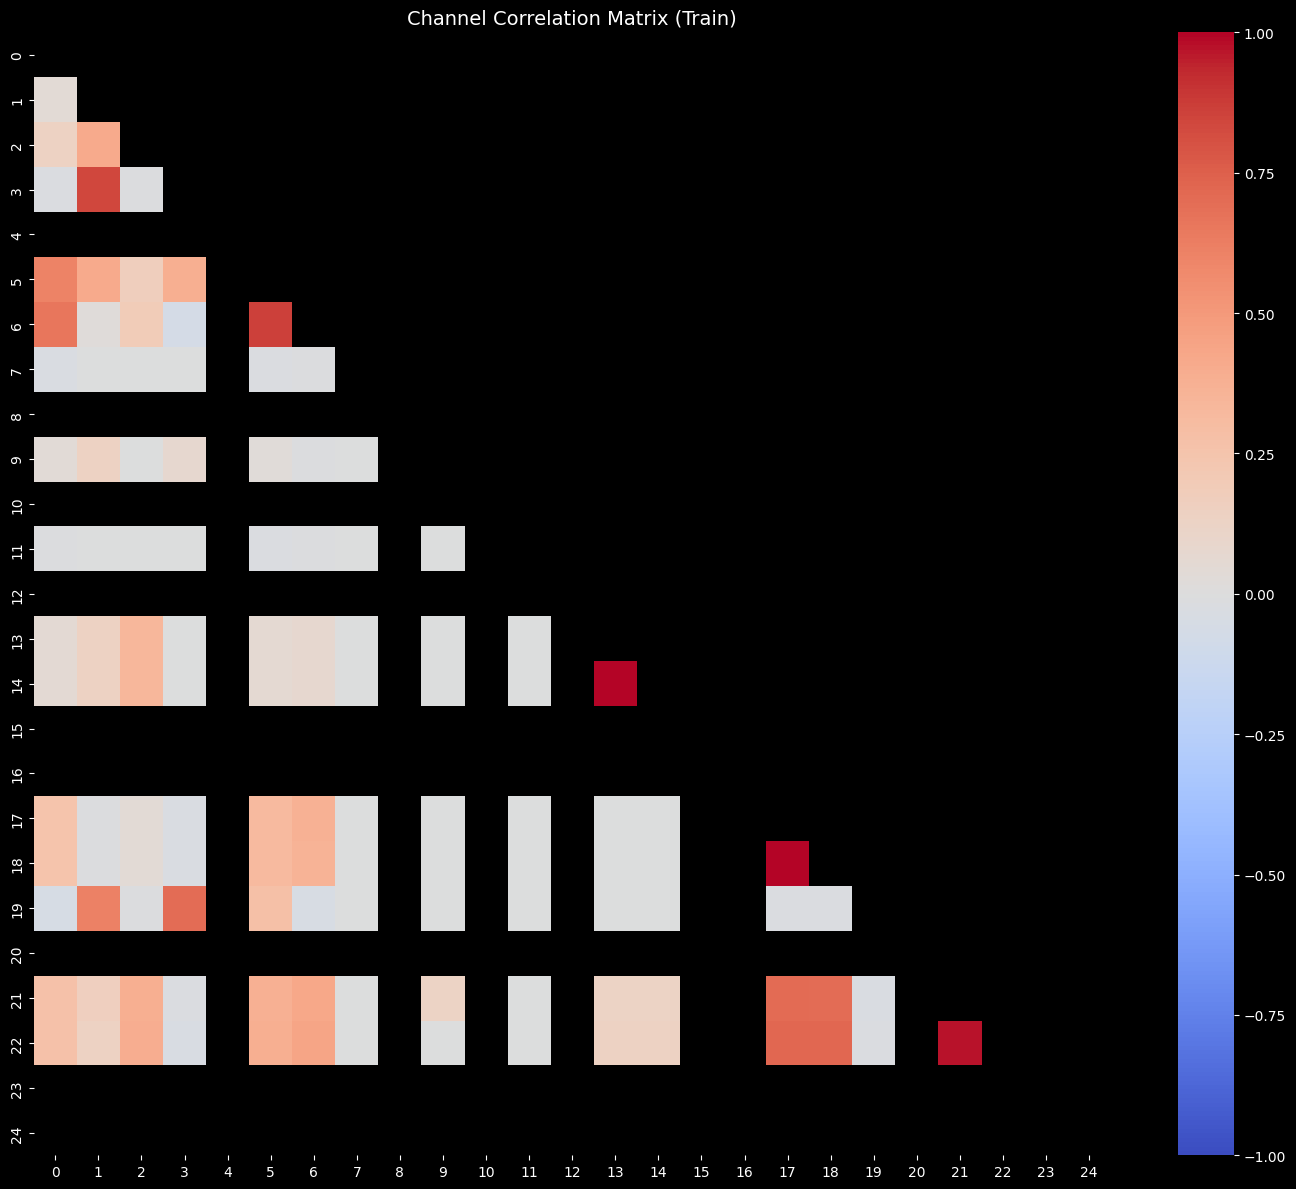

In [7]:
corr_matrix = pd.DataFrame(train_data).corr()

fig, ax = plt.subplots(figsize=(14, 12))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, cmap='coolwarm', center=0,
            annot=False, ax=ax, vmin=-1, vmax=1)
ax.set_title('Channel Correlation Matrix (Train)', fontsize=14)
plt.tight_layout()
plt.show()

## 6. Sliding Windows Analysis

Window size: 100 timesteps, Step: 10
Train windows: 278
Test windows:  841


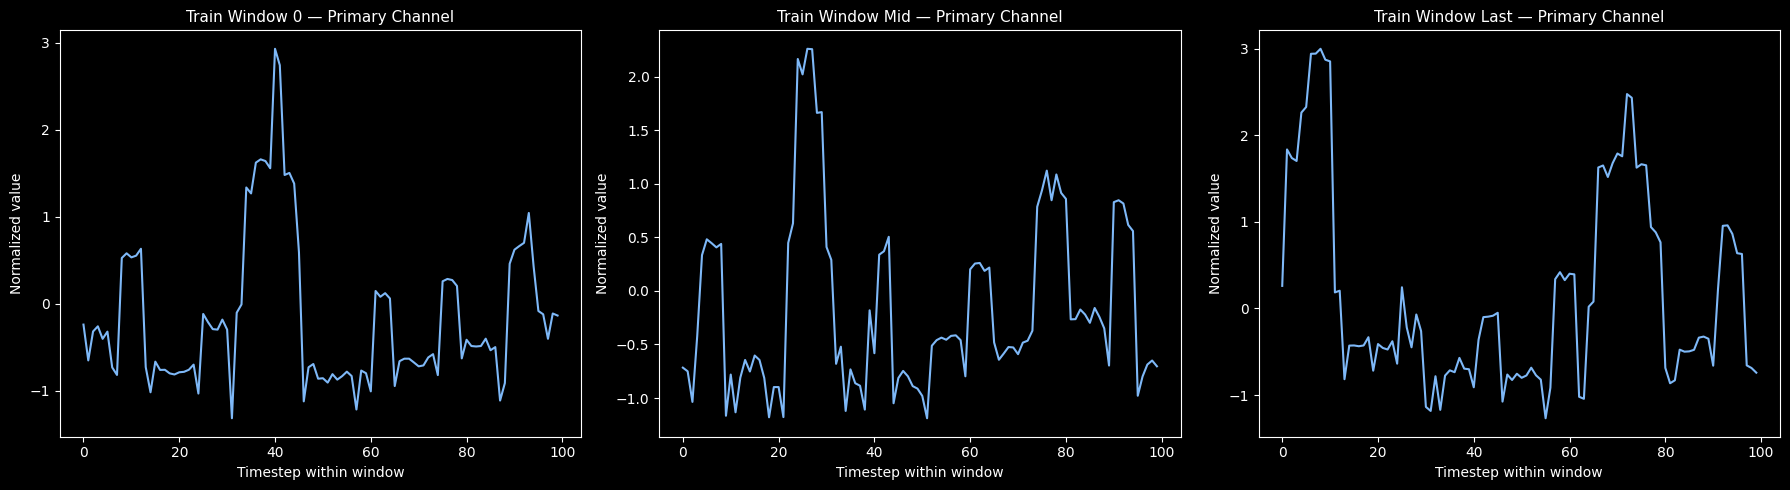

In [8]:
train_norm, test_norm, mean, std = normalize(train_data, test_data)

train_windows = sliding_windows(train_norm, WINDOW_SIZE, STEP_SIZE)
test_windows = sliding_windows(test_norm, WINDOW_SIZE, STEP_SIZE)

print(f'Window size: {WINDOW_SIZE} timesteps, Step: {STEP_SIZE}')
print(f'Train windows: {len(train_windows)}')
print(f'Test windows:  {len(test_windows)}')

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for i, (idx, title) in enumerate([(0, 'Window 0'), (len(train_windows)//2, 'Window Mid'), (-1, 'Window Last')]):
    axes[i].plot(train_windows[idx, :, 0], color='#7eb8f7', linewidth=1.5)
    axes[i].set_title(f'Train {title} — Primary Channel', fontsize=11)
    axes[i].set_xlabel('Timestep within window')
    axes[i].set_ylabel('Normalized value')

plt.tight_layout()
plt.show()

## 7. Feature Statistics

In [9]:
print('Extracting statistical features...')
train_features = extract_features(train_windows)
test_features = extract_features(test_windows)

print(f'Feature shape: {train_features.shape}')
print(f'Features per channel: 11 (mean, std, max, min, range, skew, kurt, diff_mean, diff_std, rms, zcr)')
print(f'Total features: {train_data.shape[1]} channels × 11 = {train_features.shape[1]}')

feature_df = pd.DataFrame(train_features, columns=feature_names(train_data.shape[1]))
feature_df.describe().round(4)

Extracting statistical features...
Feature shape: (278, 275)
Features per channel: 11 (mean, std, max, min, range, skew, kurt, diff_mean, diff_std, rms, zcr)
Total features: 25 channels × 11 = 275


/Users/aminazhumatayeva/Downloads/realtime-anomaly-detection-4/src/features.py:19: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  feats.append(stats.skew(windows, axis=1))
/Users/aminazhumatayeva/Downloads/realtime-anomaly-detection-4/src/features.py:20: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  feats.append(stats.kurtosis(windows, axis=1))


,ch0_mean,ch1_mean,ch2_mean,ch3_mean,ch4_mean,ch5_mean,ch6_mean,ch7_mean,ch8_mean,ch9_mean,...,ch15_zcr,ch16_zcr,ch17_zcr,ch18_zcr,ch19_zcr,ch20_zcr,ch21_zcr,ch22_zcr,ch23_zcr,ch24_zcr
count,278.0000,278.0000,278.0000,278.0000,278.0,278.0000,278.0000,278.0000,278.0,278.0000,...,278.0,278.0,278.0000,278.0000,278.0000,278.0,278.0000,278.0000,278.0,278.0
mean,0.0016,-0.0009,-0.0026,0.0001,0.0,0.0023,0.0023,0.0012,0.0,0.0009,...,0.0,0.0,0.0556,0.0548,0.0279,0.0,0.0646,0.0622,0.0,0.0
std,0.1417,0.0782,0.1108,0.0633,0.0,0.1652,0.1475,0.1271,0.0,0.0981,...,0.0,0.0,0.0209,0.0217,0.0110,0.0,0.0255,0.0256,0.0,0.0
min,-0.3286,-0.1329,-0.0772,-0.1693,0.0,-0.4322,-0.3743,-0.0373,0.0,-0.0264,...,0.0,0.0,0.0000,0.0000,0.0000,0.0,0.0202,0.0000,0.0,0.0
25%,-0.1074,-0.0778,-0.0772,-0.0477,0.0,-0.1301,-0.1002,-0.0373,0.0,-0.0264,...,0.0,0.0,0.0404,0.0404,0.0202,0.0,0.0404,0.0404,0.0,0.0
50%,-0.0308,-0.0227,-0.0772,-0.0477,0.0,-0.0752,-0.0698,-0.0373,0.0,-0.0264,...,0.0,0.0,0.0404,0.0404,0.0202,0.0,0.0606,0.0606,0.0,0.0
75%,0.1296,0.0324,0.0532,0.0738,0.0,0.1720,0.1434,-0.0373,0.0,-0.0264,...,0.0,0.0,0.0808,0.0808,0.0404,0.0,0.0808,0.0808,0.0,0.0
max,0.3363,0.1976,0.3139,0.1346,0.0,0.4466,0.4480,0.4989,0.0,0.3527,...,0.0,0.0,0.1111,0.1111,0.0606,0.0,0.1313,0.1313,0.0,0.0


## 8. Anomaly Windows — Normal vs Anomalous

Normal windows:   736
Anomalous windows: 105


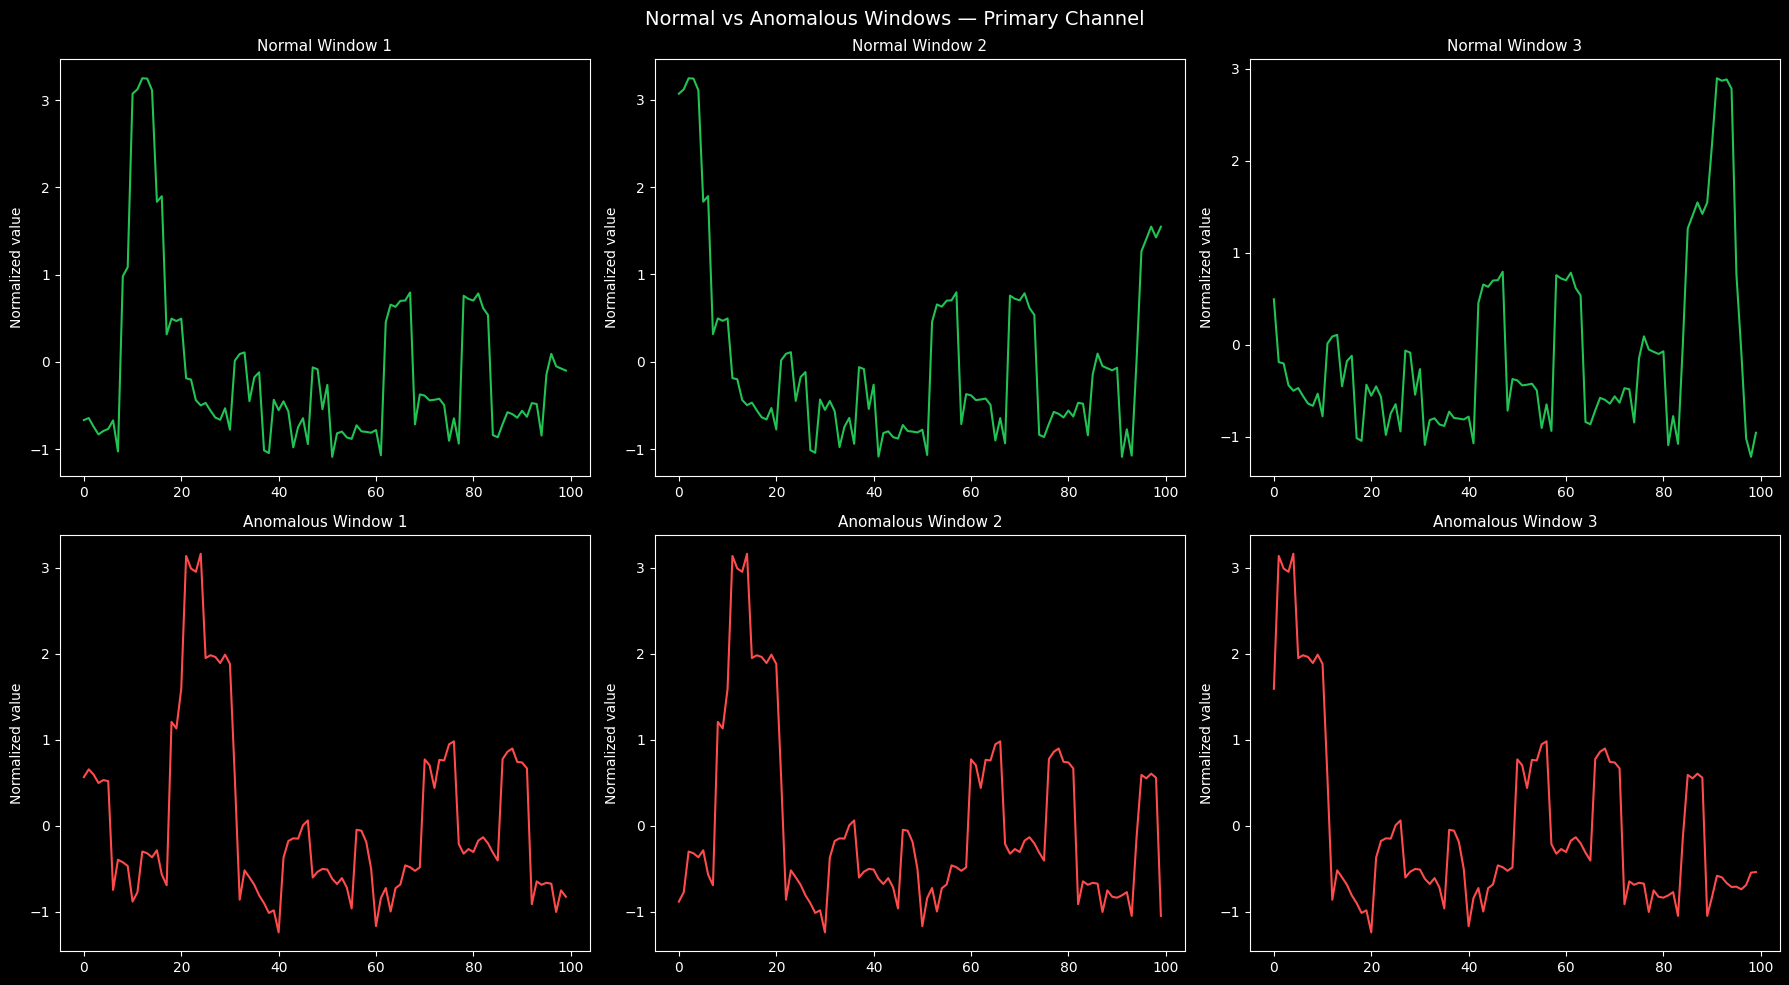

In [10]:
if labels is not None:
    window_labels = np.array([
        int(labels[i * STEP_SIZE : i * STEP_SIZE + WINDOW_SIZE].any())
        for i in range(len(test_windows))
    ])

    normal_idx = np.where(window_labels == 0)[0]
    anomaly_idx = np.where(window_labels == 1)[0]

    print(f'Normal windows:   {len(normal_idx)}')
    print(f'Anomalous windows: {len(anomaly_idx)}')

    fig, axes = plt.subplots(2, 3, figsize=(18, 10))

    for i in range(3):
        axes[0][i].plot(test_windows[normal_idx[i], :, 0], color='#21c354', linewidth=1.5)
        axes[0][i].set_title(f'Normal Window {i+1}', fontsize=11)
        axes[0][i].set_ylabel('Normalized value')

    for i in range(min(3, len(anomaly_idx))):
        axes[1][i].plot(test_windows[anomaly_idx[i], :, 0], color='#ff4b4b', linewidth=1.5)
        axes[1][i].set_title(f'Anomalous Window {i+1}', fontsize=11)
        axes[1][i].set_ylabel('Normalized value')

    plt.suptitle('Normal vs Anomalous Windows — Primary Channel', fontsize=14)
    plt.tight_layout()
    plt.show()

## 9. Summary Statistics

In [11]:
summary = pd.DataFrame({
    'Metric': ['Total timesteps (train)', 'Total timesteps (test)', 'Channels', 
               'Anomalous timesteps', 'Anomaly rate', 'Train windows', 'Test windows', 'Feature dimensions'],
    'Value': [train_data.shape[0], test_data.shape[0], train_data.shape[1],
              int(labels.sum()), f'{labels.mean()*100:.1f}%',
              len(train_windows), len(test_windows), train_features.shape[1]]
})
print(summary.to_string(index=False))

                 Metric Value
Total timesteps (train)  2872
 Total timesteps (test)  8505
               Channels    25
    Anomalous timesteps   751
           Anomaly rate  8.8%
          Train windows   278
           Test windows   841
     Feature dimensions   275
